In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, Birch, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

In [2]:
df = pd.read_csv('jopacc_system_month_november_2022_to_june_2026.csv')

In [3]:
df

,report_month,report_year,report_quarter,system,users_total,transactions_total,transaction_value_jod,user_jordanian_count,user_non_jordanian_count,user_male_count,...,ach_usd_transaction_count,ach_usd_transaction_value,ach_eur_transaction_count,ach_eur_transaction_value,ach_gbp_transaction_count,ach_gbp_transaction_value,returned_cheque_count,returned_cheque_value_jod,returned_cheque_count_rate_pct,returned_cheque_value_rate_pct
0,2022-11,2022,Q4,CliQ,523000,985000,175000000,494200,24100,342500,...,0,0,0,0,0,0,0,0,0.0,0.00
1,2022-11,2022,Q4,JoMoPay,2020000,1260000,155000000,1760000,250000,1230000,...,0,0,0,0,0,0,0,0,0.0,0.00
2,2022-11,2022,Q4,eFAWATEERcom,3580000,3630000,848000000,0,0,0,...,0,0,0,0,0,0,0,0,0.0,0.00
3,2022-12,2022,Q4,CliQ,561000,1180000,209000000,529800,26300,365000,...,0,0,0,0,0,0,0,0,0.0,0.00
4,2022-12,2022,Q4,JoMoPay,2050000,1510000,188000000,1780000,250000,1230000,...,0,0,0,0,0,0,0,0,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,2026-06,2026,Q2,ACH,0,1070000,943000000,0,0,0,...,5699,41700000,348,3070000,39,390000,0,0,0.0,0.00
210,2026-06,2026,Q2,CliQ,2310000,20960000,2150000000,2220000,94500,1400000,...,0,0,0,0,0,0,0,0,0.0,0.00
211,2026-06,2026,Q2,ECCU,0,510000,3480000000,0,0,0,...,0,0,0,0,0,0,16100,98900000,3.2,2.85
212,2026-06,2026,Q2,JoMoPay,3000000,14790000,671000000,2630000,371400,1620000,...,0,0,0,0,0,0,0,0,0.0,0.00


In [4]:
dates = pd.to_datetime(df["report_month"], format="%Y-%m")
print("Duplicate system-month rows:", df.duplicated(["system", "report_month"]).sum())
print("Missing values:", df.isna().sum().sum())
print("Invalid report_month values:", dates.isna().sum())
print("Date range:", df["report_month"].min(), "to", df["report_month"].max())
print("Systems:", sorted(df["system"].unique()))

summary = df.groupby("system")["report_month"].agg(["count", "min", "max"])
summary

Duplicate system-month rows: 0
Missing values: 0
Invalid report_month values: 0
Date range: 2022-11 to 2026-06
Systems: ['ACH', 'CliQ', 'ECCU', 'JoMoPay', 'eFAWATEERcom']


,count,min,max
system,,,
ACH,42,2023-01,2026-06
CliQ,44,2022-11,2026-06
ECCU,40,2023-03,2026-06
JoMoPay,44,2022-11,2026-06
eFAWATEERcom,44,2022-11,2026-06


In [5]:
numeric_cols = df.select_dtypes(include=np.number).columns

negative_vals = (df[numeric_cols] < 0).sum().sum()

print("Negative numerical values:",negative_vals)

Negative numerical values: 0


In [6]:
df_clean = df.copy()

df_clean["average_transaction_value_jod"] = (df_clean["transaction_value_jod"]/ df_clean["transactions_total"])

In [7]:
def standardize_feats(series):

    return (series - series.mean()) / series.std(ddof=0)

In [8]:
df_clean["relative_transaction_count"] = (df_clean.groupby("system")["transactions_total"].transform(standardize_feats))


df_clean["relative_transaction_value"] = (df_clean.groupby("system")["transaction_value_jod"].transform(standardize_feats))


df_clean["relative_average_transaction_value"] = (df_clean.groupby("system")[ "average_transaction_value_jod"].transform(standardize_feats))

In [9]:
features = [
    "relative_transaction_count",
    "relative_transaction_value",
    "relative_average_transaction_value"]


X = df_clean[features]

print("\nSelected clustering features:")
print(features)

print("\nFeature preview:")
X.head()


Selected clustering features:
['relative_transaction_count', 'relative_transaction_value', 'relative_average_transaction_value']

Feature preview:


,relative_transaction_count,relative_transaction_value,relative_average_transaction_value
0,-1.289550,-1.529123,1.399643
1,-1.237305,-1.878574,1.318851
2,-1.793118,-1.468355,1.053890
3,-1.258470,-1.474383,1.378535
4,-1.172892,-1.650632,1.373596


In [11]:
pca = PCA(n_components=0.90)

X_pca = pca.fit_transform(X)


print(
    "\nNumber of PCA components retained:",X_pca.shape[1])


print(
    "Explained variance ratio:",pca.explained_variance_ratio_)


print(
    "Total variance explained:",
    round(pca.explained_variance_ratio_.sum()* 100,2),"%")


Number of PCA components retained: 2
Explained variance ratio: [0.73865762 0.24593784]
Total variance explained: 98.46 %


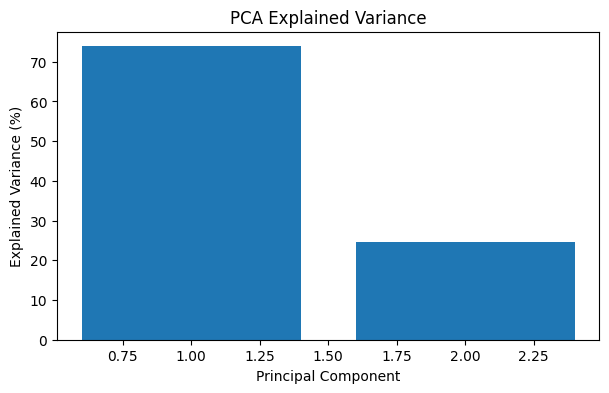

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7, 4))

components = range(1,len(pca.explained_variance_ratio_) + 1)

plt.bar(components,pca.explained_variance_ratio_* 100)

plt.xlabel("Principal Component")

plt.ylabel("Explained Variance (%)")

plt.title("PCA Explained Variance")

plt.show()

In [13]:
k_models = {
    "K-Means++": lambda k: KMeans(n_clusters=k,init="k-means++",n_init=30,random_state=42),
    "K-Means Random": lambda k: KMeans(n_clusters=k,init="random",n_init=30,random_state=42),
    "Hierarchical ward Linkage": lambda k:AgglomerativeClustering(n_clusters=k,linkage="ward"),
    "BIRCH": lambda k: Birch(n_clusters=k)}

In [14]:
k_results = []

for algorithm_name, create_model in k_models.items():

    for k in range(2, 9):
        model = create_model(k)
        labels = model.fit_predict( X_pca)

        silhouette = silhouette_score(X_pca,labels)
        calinski = (calinski_harabasz_score(X_pca,labels))
        davies = (davies_bouldin_score( X_pca,labels))

        k_results.append({

            "Algorithm":algorithm_name,

            "k":k,

            "Silhouette Score":silhouette,

            "Calinski-Harabasz":calinski,

            "Davies-Bouldin": davies,})

In [18]:
k_results_df = pd.DataFrame(k_results)

print("\nall k results:")

print(k_results_df)


all k results:
                    Algorithm  k  Silhouette Score  Calinski-Harabasz  \
0                   K-Means++  2          0.437419         227.984641   
1                   K-Means++  3          0.387028         203.405459   
2                   K-Means++  4          0.447290         232.352569   
3                   K-Means++  5          0.451800         234.131535   
4                   K-Means++  6          0.418023         238.985373   
5                   K-Means++  7          0.398751         227.616108   
6                   K-Means++  8          0.396423         223.955825   
7              K-Means Random  2          0.437419         227.984641   
8              K-Means Random  3          0.387028         203.405459   
9              K-Means Random  4          0.447290         232.352569   
10             K-Means Random  5          0.451800         234.131535   
11             K-Means Random  6          0.418023         238.985373   
12             K-Means Random  7   

In [19]:
best_k_results = []


for algorithm_name in (k_results_df["Algorithm"].unique()):

    algorithm_results = (k_results_df[k_results_df["Algorithm"]== algorithm_name])

    best_row = (algorithm_results.loc[algorithm_results["Silhouette Score"].idxmax()])

    best_k_results.append(best_row)

best_k_df = (pd.DataFrame(best_k_results).reset_index(drop=True))

print(
    "best k for each clustering algorithm")


print(best_k_df.round(4).to_string(index=False))

best k for each clustering algorithm
                Algorithm  k  Silhouette Score  Calinski-Harabasz  Davies-Bouldin
                K-Means++  5            0.4518           234.1315          0.7593
           K-Means Random  5            0.4518           234.1315          0.7593
Hierarchical ward Linkage  5            0.4321           216.2084          0.7813
                    BIRCH  2            0.3998           160.2368          0.9527


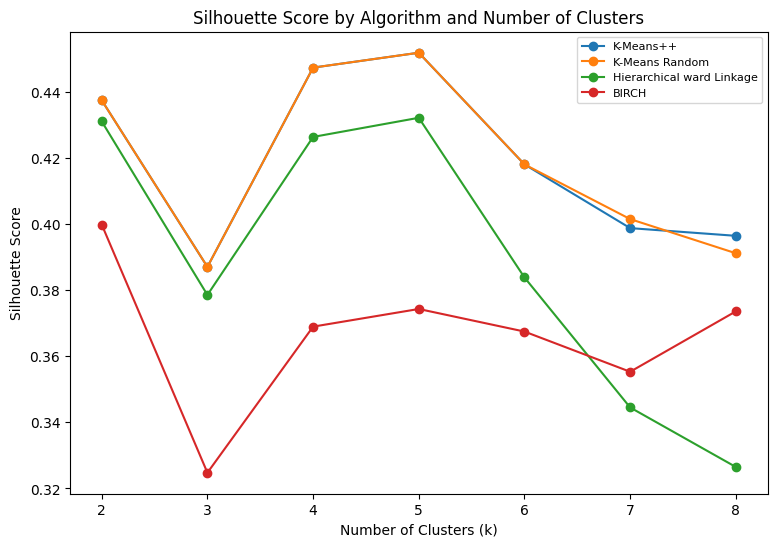

In [20]:
plt.figure(figsize=(9, 6))


for algorithm_name in (k_results_df["Algorithm"].unique()):

    algorithm_data = (k_results_df[k_results_df["Algorithm"]== algorithm_name])

    plt.plot(algorithm_data["k"], algorithm_data["Silhouette Score"],marker="o",label=algorithm_name)


plt.xlabel("Number of Clusters (k)")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score by Algorithm and Number of Clusters")

plt.legend(fontsize=8)

plt.show()

In [21]:
from sklearn.mixture import GaussianMixture

In [ ]:
for eps in [0.4,0.5,0.6]:

    model = DBSCAN(eps=eps,min_samples=4)
    labels = model.fit_predict(X_pca)

    clusters = len(set(labels)) - (1 if -1 in labels else 0)

    noise = (labels == -1).sum()

    print(
        "eps =", eps,
        "| clusters =", clusters,
        "| noise =", noise)

eps = 0.4 | clusters = 3 | noise = 20
eps = 0.5 | clusters = 1 | noise = 13
eps = 0.6 | clusters = 1 | noise = 11


In [37]:
gmm_results = []
for n_components in [2,3,4,5]:

    model = GaussianMixture(n_components=n_components, n_init=10, random_state=42)
    labels = model.fit_predict(X_pca)

    silhouette = silhouette_score(X_pca,labels)

    gmm_results.append({"n_components": n_components,"silhouette": silhouette})

    print("n_components =", n_components,"| silhouette =", round(silhouette, 4))

    

n_components = 2 | silhouette = 0.4325
n_components = 3 | silhouette = 0.3932
n_components = 4 | silhouette = 0.4093
n_components = 5 | silhouette = 0.2719


In [38]:
models = {
    "K-Means random": KMeans(n_clusters=5, init="random", n_init=30, random_state=42),
    "K-Means++": KMeans(n_clusters=5, init="k-means++", n_init=30, random_state=42),
    "Agglomerative ward": AgglomerativeClustering(n_clusters=5, linkage="ward"),
    "DBSCAN": DBSCAN(eps=0.4, min_samples=4),
    "Gaussian Mixture": GaussianMixture(n_components=4, n_init=10, random_state=42),
    "BIRCH": Birch(n_clusters=2, threshold=0.5)}

rows = []
labels_by_name = {}
for name, model in models.items():
    labels = model.fit_predict(X_pca)
    labels_by_name[name] = labels
    non_noise = labels != -1
    evaluation_labels = labels[non_noise]
    clusters = len(np.unique(evaluation_labels))
    row = {
        "algorithm": name,
        "clusters": clusters,
        "noise": int((labels == -1).sum())}
    if clusters >= 2:
        row.update({
            "silhouette": silhouette_score(X_pca[non_noise], evaluation_labels),
            "davies_bouldin": davies_bouldin_score(X_pca[non_noise], evaluation_labels),
            "calinski_harabasz": calinski_harabasz_score(X_pca[non_noise], evaluation_labels)})
    rows.append(row)

comparison = pd.DataFrame(rows)
comparison.round(4)


,algorithm,clusters,noise,silhouette,davies_bouldin,calinski_harabasz
0,K-Means random,5,0,0.4518,0.7593,234.1315
1,K-Means++,5,0,0.4518,0.7593,234.1315
2,Agglomerative ward,5,0,0.4321,0.7813,216.2084
3,DBSCAN,3,20,0.0771,0.9811,11.3781
4,Gaussian Mixture,4,0,0.4093,0.7907,192.0087
5,BIRCH,2,0,0.3998,0.9527,160.2368
